In [34]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=30)

In [35]:
import matplotlib.pyplot as plt

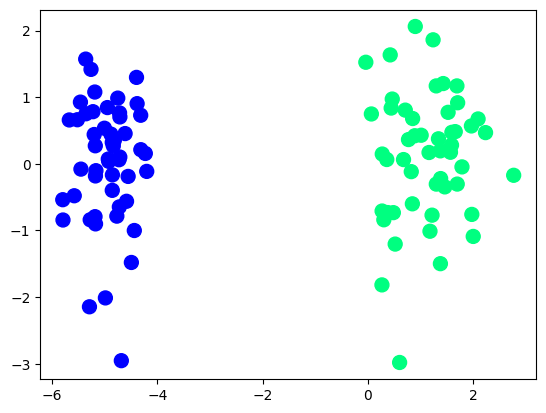

In [36]:
plt.scatter(X[:,0], X[:,1], c=y,cmap='winter',s=100)

In [37]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    penalty=None,
    solver='sag'  # or 'newton-cg' or 'saga'
)


In [38]:
lr.fit(X,y)

/Users/pratyushtiwari/Desktop/Machine Learning CampusX/myvenv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'sag'
,max_iter,100
,multi_class,'deprecated'


In [39]:
print(lr.coef_, lr.intercept_)

[[3.64689183 0.1418364 ]] [4.2884042]


In [40]:
m1 = -(lr.coef_[0][0]/lr.coef_[0][1])
b1 = -(lr.intercept_/lr.coef_[0][1]) 

In [41]:
x_input = np.linspace(-3,3,100)
y_input = m1*x_input + b1

In [48]:
def gd(X,y):
    
    X = np.insert(X,0,1,axis=1)  # add bias term
    weights = np.ones(X.shape[1])
    lr = 0.5
    
    for i in range(5000):
        
        y_hat = sigmoid(np.dot(X,weights))
        weights += lr * np.dot((y-y_hat),X)/X.shape[0]
    
    return weights[1:], weights[0]
    

In [49]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [50]:
coef_, intercept_ = gd(X,y)

In [51]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [52]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m1*x_input1 + b1

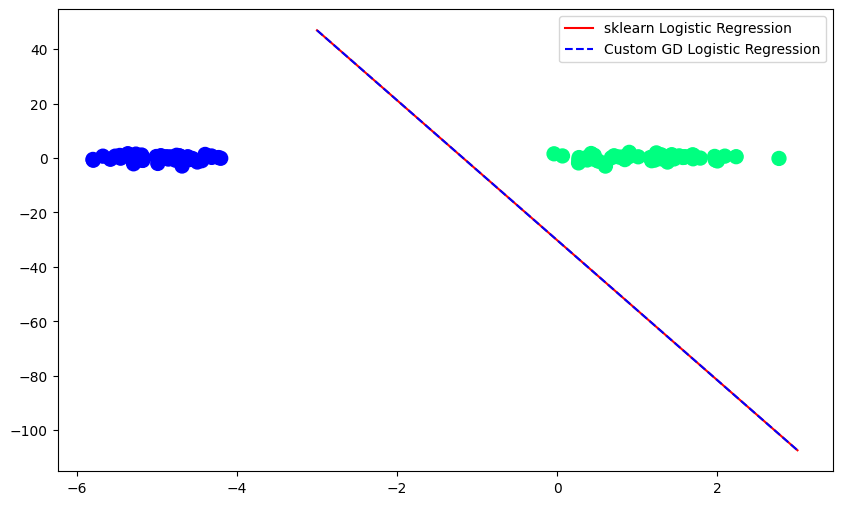

In [53]:
plt.figure(figsize=(10,6))
plt.plot(x_input, y_input, color='red', label='sklearn Logistic Regression')
plt.plot(x_input1, y_input1, color='blue', linestyle='--', label='Custom GD Logistic Regression')
plt.scatter(X[:,0], X[:,1], c=y,cmap='winter',s=100)
plt.legend()
plt.show()